In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
RandomForestClassifier,AdaBoostClassifier,BaggingClassifier,GradientBoostingClassifier,VotingClassifier
)
from sklearn.metrics import (
accuracy_score,confusion_matrix,classification_report
)
from xgboost import XGBClassifier

In [2]:
df=pd.read_csv("Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape

(10000, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [5]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [31]:
X=df.drop(["churn",'customer_id'],axis=1)

In [32]:
y=df['churn']

In [33]:
X.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [10]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: churn, dtype: int64

In [34]:
numerical_cols=X.select_dtypes(exclude="object").columns.tolist()

In [35]:
numerical_cols

['credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary']

In [36]:
categorical_cols=X.select_dtypes(include='object').columns.tolist()

In [37]:
categorical_cols

['country', 'gender']

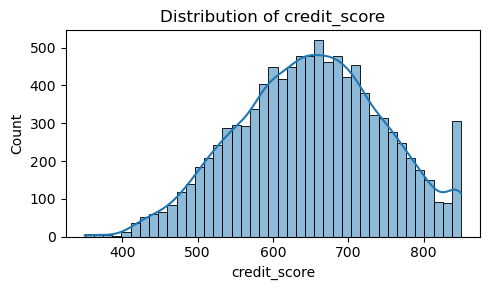

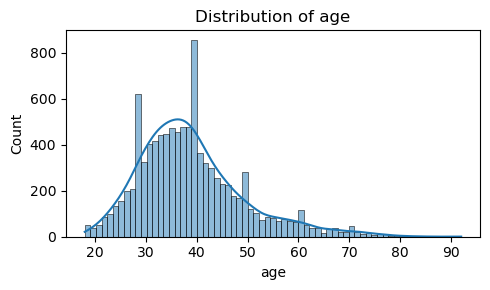

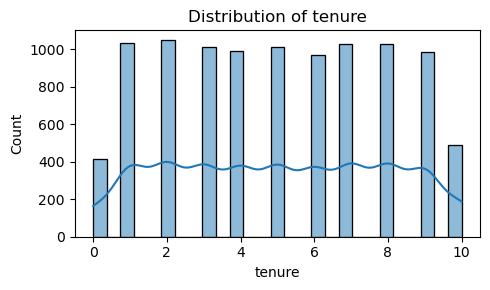

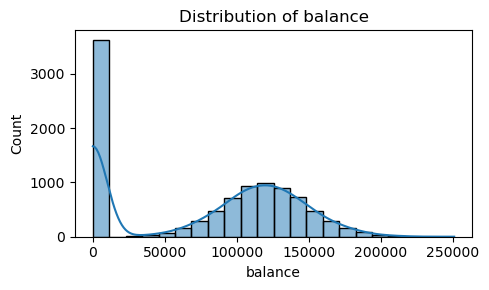

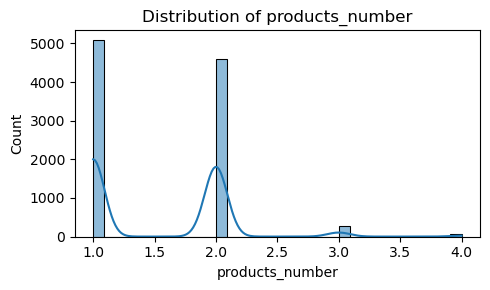

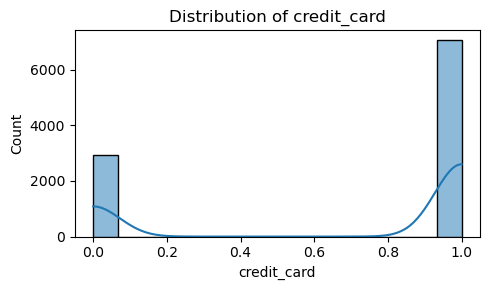

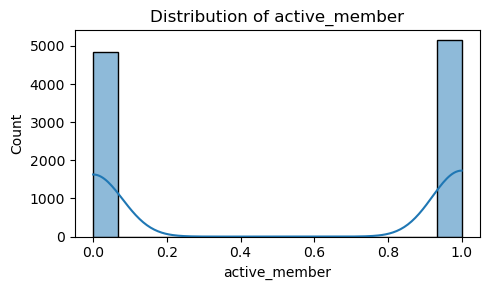

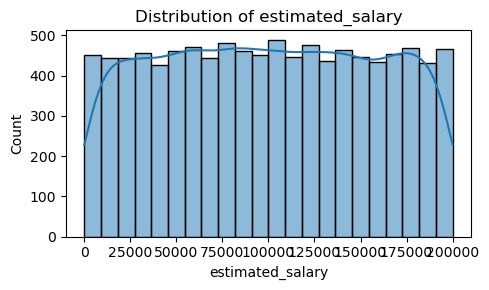

In [38]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(
        data=X[col],
        kde=True,
        
    )
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

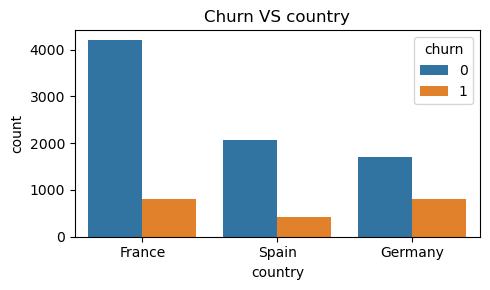

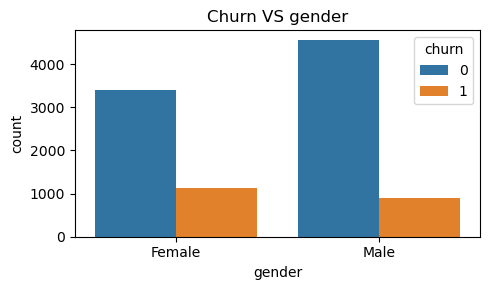

In [39]:
for col in categorical_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(
        x=col,hue='churn',data=df
    )
    plt.title(f'Churn VS {col}')
    plt.tight_layout()
    

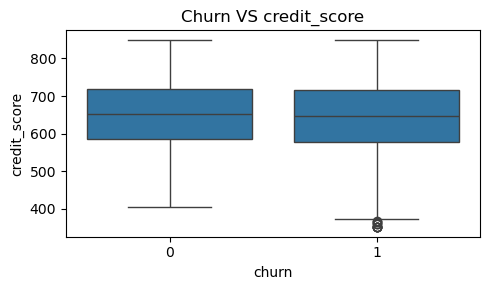

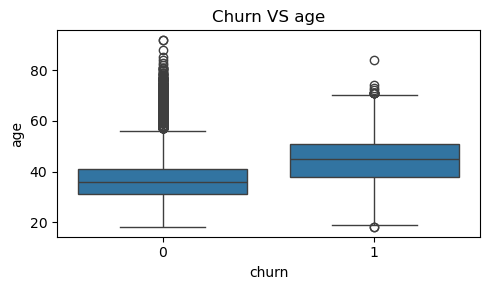

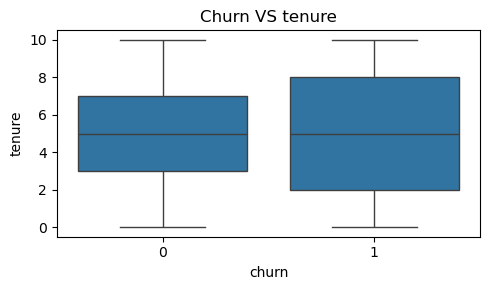

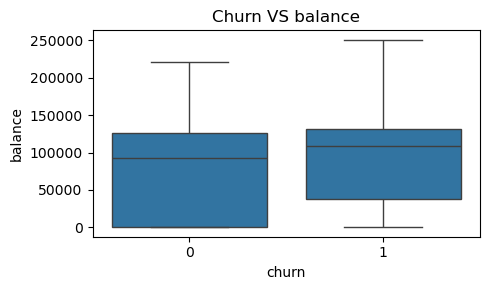

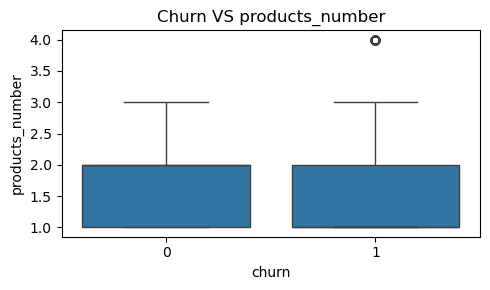

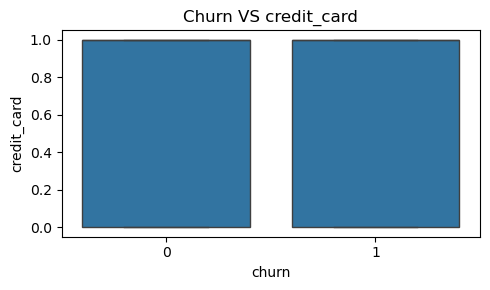

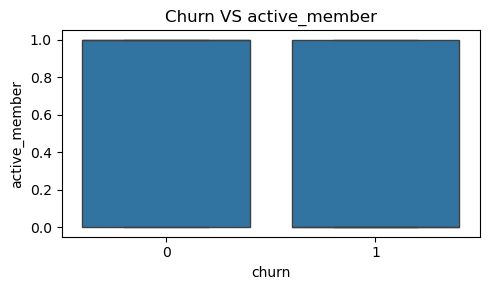

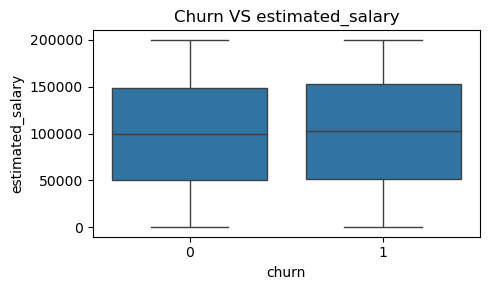

In [40]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(
        x='churn',y=col,data=df
    )
    plt.title(f'Churn VS {col}')
    plt.tight_layout()


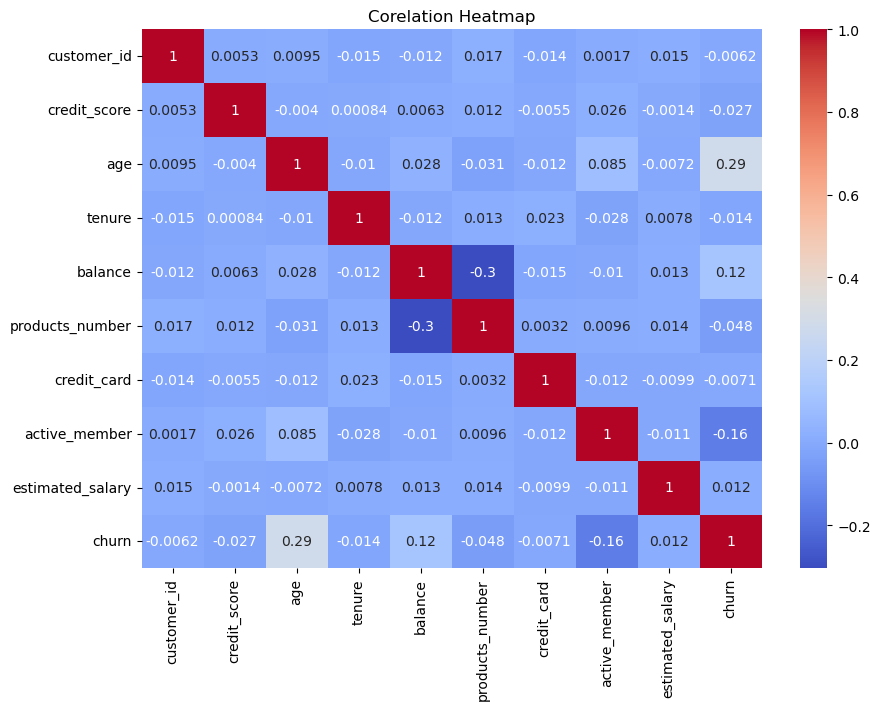

In [41]:
plt.figure(figsize=(10,7))
sns.heatmap(
    df.corr(numeric_only=True),annot=True,cmap='coolwarm'
)
plt.title('Corelation Heatmap')
plt.show()

In [45]:
cor=df.corr(numeric_only=True)
cor['churn'].sort_values(ascending=False)

churn               1.000000
age                 0.285323
balance             0.118533
estimated_salary    0.012097
customer_id        -0.006248
credit_card        -0.007138
tenure             -0.014001
credit_score       -0.027094
products_number    -0.047820
active_member      -0.156128
Name: churn, dtype: float64

In [46]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_cols),
        ('cat',OneHotEncoder(),categorical_cols)
    ]
)

In [53]:
X.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [54]:
lr_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
]
    
)

In [55]:
lr_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
y_pred_lr=lr_model.predict(X_test)

In [60]:
print('Accuracy',accuracy_score(y_test,y_pred_lr))
print('\n Confusion Metrix')
print(confusion_matrix(y_test,y_pred_lr))
print('\n Classification Report')
print(classification_report(y_test,y_pred_lr))

Accuracy 0.811

 Confusion Metrix
[[1543   64]
 [ 314   79]]

 Classification Report
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [61]:
from sklearn.metrics import roc_auc_score
y_prob=lr_model.predict_proba(X_test)[:,1]
print("ROC-AUC",roc_auc_score(y_test,y_prob))

ROC-AUC 0.7788618813049144


In [64]:
# Decision Tree Pipeline

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42,max_depth=3))
])

# Fit
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Probability for ROC-AUC
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Results
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("Decision Tree ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Decision Tree Accuracy: 0.8485

Decision Tree Confusion Matrix:
[[1527   80]
 [ 223  170]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.68      0.43      0.53       393

    accuracy                           0.85      2000
   macro avg       0.78      0.69      0.72      2000
weighted avg       0.83      0.85      0.83      2000

Decision Tree ROC-AUC: 0.7889695369020079


In [65]:


# Random Forest Pipeline
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Fit
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Probability for ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Results
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Accuracy: 0.8635

Random Forest Confusion Matrix:
[[1545   62]
 [ 211  182]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.46      0.57       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Random Forest ROC-AUC: 0.8562530975328991


In [66]:


# Naive Bayes Pipeline
nb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GaussianNB())
])

# Fit
nb_model.fit(X_train, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test)

# Probability for ROC-AUC
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

# Results
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nNaive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

print("Naive Bayes ROC-AUC:", roc_auc_score(y_test, y_prob_nb))

Naive Bayes Accuracy: 0.82

Naive Bayes Confusion Matrix:
[[1490  117]
 [ 243  150]]

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1607
           1       0.56      0.38      0.45       393

    accuracy                           0.82      2000
   macro avg       0.71      0.65      0.67      2000
weighted avg       0.80      0.82      0.81      2000

Naive Bayes ROC-AUC: 0.7957203772933619


In [68]:
from sklearn.neighbors import KNeighborsClassifier

# KNN Pipeline
knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=7))
])

# Fit
knn_model.fit(X_train, y_train)

# Prediction
y_pred_knn = knn_model.predict(X_test)

# Probability for ROC-AUC
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Results
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

print("KNN ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

KNN Accuracy: 0.8435

KNN Confusion Matrix:
[[1533   74]
 [ 239  154]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.68      0.39      0.50       393

    accuracy                           0.84      2000
   macro avg       0.77      0.67      0.70      2000
weighted avg       0.83      0.84      0.83      2000

KNN ROC-AUC: 0.7878176109292837


In [71]:
from sklearn.svm import SVC

# SVM Pipeline
svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(probability=True, random_state=42))
])

# Fit
svm_model.fit(X_train, y_train)

# Prediction
y_pred_svm = svm_model.predict(X_test)

# Probability for ROC-AUC
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Results
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("SVM ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

SVM Accuracy: 0.8575

SVM Confusion Matrix:
[[1569   38]
 [ 247  146]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1607
           1       0.79      0.37      0.51       393

    accuracy                           0.86      2000
   macro avg       0.83      0.67      0.71      2000
weighted avg       0.85      0.86      0.84      2000

SVM ROC-AUC: 0.8254772773695236


In [73]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting Pipeline
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42,max_depth=3))
])

# Fit
gb_model.fit(X_train, y_train)

# Prediction
y_pred_gb = gb_model.predict(X_test)

# Probability for ROC-AUC
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Results
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

print("\nGradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Gradient Boosting Accuracy: 0.864

Gradient Boosting Confusion Matrix:
[[1542   65]
 [ 207  186]]

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.74      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Gradient Boosting ROC-AUC: 0.8715709420141842


In [74]:
from xgboost import XGBClassifier

# XGBoost Pipeline
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss'
    ))
])

# Fit
xgb_model.fit(X_train, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test)

# Probability for ROC-AUC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Results
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Accuracy: 0.8585

XGBoost Confusion Matrix:
[[1522   85]
 [ 198  195]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1607
           1       0.70      0.50      0.58       393

    accuracy                           0.86      2000
   macro avg       0.79      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

XGBoost ROC-AUC: 0.8506913930941444


In [75]:
from sklearn.ensemble import BaggingClassifier

# Bagging Pipeline
bag_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', BaggingClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Fit
bag_model.fit(X_train, y_train)

# Prediction
y_pred_bag = bag_model.predict(X_test)

# Probability for ROC-AUC
y_prob_bag = bag_model.predict_proba(X_test)[:, 1]

# Results
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

print("\nBagging Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_bag))

print("\nBagging Classification Report:")
print(classification_report(y_test, y_pred_bag))

print("Bagging ROC-AUC:", roc_auc_score(y_test, y_prob_bag))

Bagging Accuracy: 0.857

Bagging Confusion Matrix:
[[1521   86]
 [ 200  193]]

Bagging Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1607
           1       0.69      0.49      0.57       393

    accuracy                           0.86      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.85      0.86      0.85      2000

Bagging ROC-AUC: 0.8510397418419098


In [76]:
from sklearn.ensemble import ExtraTreesClassifier


# Extra Trees Pipeline
et_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ExtraTreesClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Fit
et_model.fit(X_train, y_train)

# Prediction
y_pred_et = et_model.predict(X_test)

# Probability for ROC-AUC
y_prob_et = et_model.predict_proba(X_test)[:, 1]

# Results
print("Extra Trees Accuracy:", accuracy_score(y_test, y_pred_et))

print("\nExtra Trees Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_et))

print("\nExtra Trees Classification Report:")
print(classification_report(y_test, y_pred_et))

print("Extra Trees ROC-AUC:", roc_auc_score(y_test, y_prob_et))

Extra Trees Accuracy: 0.8675

Extra Trees Confusion Matrix:
[[1553   54]
 [ 211  182]]

Extra Trees Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

Extra Trees ROC-AUC: 0.844558871730074


In [80]:
models = {
    "Logistic Regression": (y_pred_lr, y_prob),
    "Decision Tree": (y_pred_dt, y_prob_dt),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "Naive Bayes": (y_pred_nb, y_prob_nb),
    "KNN": (y_pred_knn, y_prob_knn),
    "SVM": (y_pred_svm, y_prob_svm),
    "Gradient Boosting": (y_pred_gb, y_prob_gb),
    "XGBoost": (y_pred_xgb, y_prob_xgb),
    "Bagging": (y_pred_bag, y_prob_bag),
    "Extra Trees": (y_pred_et, y_prob_et)
}

for name, (pred, prob) in models.items():
    print(f"{name}")
    print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
    print(f"ROC-AUC:  {roc_auc_score(y_test, prob):.3f}")
    print("-" * 30)

Logistic Regression
Accuracy: 0.811
ROC-AUC:  0.779
------------------------------
Decision Tree
Accuracy: 0.849
ROC-AUC:  0.789
------------------------------
Random Forest
Accuracy: 0.864
ROC-AUC:  0.856
------------------------------
Naive Bayes
Accuracy: 0.820
ROC-AUC:  0.796
------------------------------
KNN
Accuracy: 0.844
ROC-AUC:  0.788
------------------------------
SVM
Accuracy: 0.858
ROC-AUC:  0.825
------------------------------
Gradient Boosting
Accuracy: 0.864
ROC-AUC:  0.872
------------------------------
XGBoost
Accuracy: 0.859
ROC-AUC:  0.851
------------------------------
Bagging
Accuracy: 0.857
ROC-AUC:  0.851
------------------------------
Extra Trees
Accuracy: 0.868
ROC-AUC:  0.845
------------------------------


In [81]:
results = []

for name, (pred, prob) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

print(results_df)

                 Model  Accuracy   ROC-AUC
6    Gradient Boosting    0.8640  0.871571
2        Random Forest    0.8635  0.856253
8              Bagging    0.8570  0.851040
7              XGBoost    0.8585  0.850691
9          Extra Trees    0.8675  0.844559
5                  SVM    0.8575  0.825477
3          Naive Bayes    0.8200  0.795720
1        Decision Tree    0.8485  0.788970
4                  KNN    0.8435  0.787818
0  Logistic Regression    0.8110  0.778862


In [83]:
best_model = results_df.iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model       Gradient Boosting
Accuracy                0.864
ROC-AUC              0.871571
Name: 6, dtype: object


In [86]:
import joblib

# Best model = Gradient Boosting Pipeline
best_model = gb_model

# Feature names used by the model
features = X.columns.tolist()

# Save complete model pipeline
joblib.dump(best_model, 'customer_churn_model.pkl')

# Save feature names
joblib.dump(features, 'customer_churn_features.pkl')

print("Model file created: customer_churn_model.pkl")
print("Features file created: customer_churn_features.pkl")
print("\nFeatures:")
print(features)

Model file created: customer_churn_model.pkl
Features file created: customer_churn_features.pkl

Features:
['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


In [87]:
# Load saved files
loaded_model = joblib.load('customer_churn_model.pkl')
features = joblib.load('customer_churn_features.pkl')

# New customer data
new_customer = pd.DataFrame([{
    'credit_score': 650,
    'country': 'France',
    'gender': 'Female',
    'age': 40,
    'tenure': 5,
    'balance': 100000,
    'products_number': 1,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 50000
}])

# Prediction
prediction = loaded_model.predict(new_customer)[0]

# Churn probability
probability = loaded_model.predict_proba(new_customer)[0][1]

if prediction == 1:
    print("Prediction: Customer will churn")
else:
    print("Prediction: Customer will not churn")

print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: Customer will not churn
Churn Probability: 16.68 %


In [88]:
new_customer = pd.DataFrame([{
    'credit_score': 500,
    'country': 'Germany',
    'gender': 'Female',
    'age': 55,
    'tenure': 1,
    'balance': 150000,
    'products_number': 1,
    'credit_card': 0,
    'active_member': 0,
    'estimated_salary': 40000
}])

prediction = loaded_model.predict(new_customer)[0]
probability = loaded_model.predict_proba(new_customer)[0][1]

if prediction == 1:
    print("Prediction: Customer will churn")
else:
    print("Prediction: Customer will not churn")

print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: Customer will churn
Churn Probability: 91.16 %
